In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv('dirty_cafe_sales1.csv')
data.head()

,Unnamed: 0,Transaction ID,Transaction Date,Menu,Category,Menu ID,Qty,Price,Total Spent,Payment Method,Order Type
0,0,SUN-3835107,2023-06-22,Caramel Machiato,Drinks,DRK-04,3,38000,114000,Debit Card,Dine In
1,1,SUN-8191346,2023-07-06,Caramel Machiato,Drinks,DRK-04,1,38000,38000,unknown,Take Away
2,2,SUN-7920383,2023-10-03,Club Sandwich,Food,FOD-05,3,45000,135000,Debit Card,Take Away
3,3,SUN-6464422,2023-12-13,Grill Chicken Caesar Salad,Food,unknown,3,42000,126000,Debit Card,Dine In
4,4,SUN-2014718,2023-01-13,Buttermilk Fried Chicken,Food,FOD-01,1,48000,48000,Debit Card,Take Away


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        10000 non-null  int64 
 1   Transaction ID    10000 non-null  object
 2   Transaction Date  9975 non-null   object
 3   Menu              9560 non-null   object
 4   Category          9702 non-null   object
 5   Menu ID           9803 non-null   object
 6   Qty               9737 non-null   object
 7   Price             9717 non-null   object
 8   Total Spent       9631 non-null   object
 9   Payment Method    9556 non-null   object
 10  Order Type        9638 non-null   object
dtypes: int64(1), object(10)
memory usage: 859.5+ KB


In [5]:
data.isna().sum()

Unnamed: 0            0
Transaction ID        0
Transaction Date     25
Menu                440
Category            298
Menu ID             197
Qty                 263
Price               283
Total Spent         369
Payment Method      444
Order Type          362
dtype: int64

In [6]:
for i in data:
    print(data[i].unique())

[   0    1    2 ... 9997 9998 9999]
['SUN-3835107' 'SUN-8191346' 'SUN-7920383' ... 'SUN-3471357' 'SUN-3113015'
 'SUN-8166774']
['2023-06-22' '2023-07-06' '2023-10-03' '2023-12-13' '2023-01-13'
 '2023-02-22' '2023-10-28' '2023-04-01' '2023-04-24' '2023-11-14'
 '2023-06-04' '2023-04-10' '2023-10-30' '2023-04-04' '2023-05-30'
 '2023-08-23' '2023-07-20' '2023-02-01' '2023-01-11' 'missing'
 '2023-11-02' '2023-07-16' '2023-10-26' '2023-05-01' '2023-06-15'
 '2023-10-15' '2023-02-15' '2023-04-21' '2023-12-23' '2023-02-18'
 '2023-05-20' '2023-05-28' '2023-11-26' '2023-03-16' '2023-07-03'
 '2023-04-06' '2023-01-08' '2023-10-01' '2023-01-23' '2023-04-13'
 '2023-07-01' '2023-06-27' '2023-02-12' '2023-12-24' '2023-12-18'
 '2023-02-03' '2023-09-22' '2023-04-17' '2023-07-17' '2023-12-04'
 '2023-04-12' '2023-02-28' '2023-04-28' '2023-12-21' '2023-06-03'
 '2023-07-08' '2023-08-16' '2023-06-16' '2023-10-11' '2023-05-13'
 '2023-08-12' '2023-10-10' '2023-12-01' '2023-06-05' '2023-01-15'
 '2023-09-20' '202

In [7]:
data = data.drop(columns='Unnamed: 0')

In [8]:
data

,Transaction ID,Transaction Date,Menu,Category,Menu ID,Qty,Price,Total Spent,Payment Method,Order Type
0,SUN-3835107,2023-06-22,Caramel Machiato,Drinks,DRK-04,3,38000,114000,Debit Card,Dine In
1,SUN-8191346,2023-07-06,Caramel Machiato,Drinks,DRK-04,1,38000,38000,unknown,Take Away
2,SUN-7920383,2023-10-03,Club Sandwich,Food,FOD-05,3,45000,135000,Debit Card,Take Away
3,SUN-6464422,2023-12-13,Grill Chicken Caesar Salad,Food,unknown,3,42000,126000,Debit Card,Dine In
4,SUN-2014718,2023-01-13,Buttermilk Fried Chicken,Food,FOD-01,1,48000,48000,Debit Card,Take Away
...,...,...,...,...,...,...,...,...,...,...
9995,SUN-8869909,2023-10-02,Choco Lava Cake,Dessert,DST-04,1,missing,35000,Debit Card,Online Order
9996,SUN-6179068,2023-04-16,Espreso Single,Drinks,DRK-01,3,22000,66000,Debit Card,missing
9997,SUN-3471357,2023-06-21,Classic Tirmaisu,Dessert,DST-01,2,38000,76000,Digital Wallet,Dine In
9998,SUN-3113015,2023-07-17,Iced Americano,Drinks,DRK-02,3,28000,84000,Digital Wallet,Dine In


In [9]:
data['Transaction ID'].duplicated().sum()

np.int64(0)

In [10]:
data.isna().sum()

Transaction ID        0
Transaction Date     25
Menu                440
Category            298
Menu ID             197
Qty                 263
Price               283
Total Spent         369
Payment Method      444
Order Type          362
dtype: int64

1. TransactionID has no duplicated so just remove the white spaces and we don't have to remove the SUN prefix and make it integer there is no use
2. Transaction Date there is missing values and error column values handle them to Nan and handle the missing values by median and change them to date time format
3. Menu check whether it has special character and remove the white spaces and standardize the text , it has missing values of 440 check whether we can get it from any column or use mode as it is categorical column 
4. Category missing values we can get it from the Menu like one recepi has many order so in those orders we can se  that for one category is ther and for another it is misisng and staandardize the text and handle the whitespace
5. Menu Id yes even with this we can get it from the Menu and handle the strip white spaces 
6. Qty we can use median and there is error values make it to nan and then do the median and lter make it to int
7. Price we grouby menu and qty we can get the exact price and there might still be few issing values but the sacle is less and ther value called missing make nan and later at all make it unknown or use median
8. total spent obviosuly it mustve come from qty and price so we can stil handle the missing values  make it is int dtype
9. Payment method we have missing and error values make it to nan and later make it cash or use mode or you can let it remain the empty like it is small scale like around 4.4% is the missing values so we can flag it off
10. Order type we have missing and error values need to flag off it as nan and th emissing values we can mode it 

Refined insights :

Step 0: Setup

- Drop the unnamed index column.
- Strip the whitespace on all the text columns. It found nothing to fix, but it's harmless.
- Turn error, unknown and missing into NaN in every column except Transaction ID.
- Check the missing counts against the table I gave you.

Step 1: Fix the types
5. Transaction ID: leave it as a string, with no changes.
6. Transaction Date: convert it to datetime, and anything unparseable becomes NaT.
7. Qty, Price, Total Spent: convert them to numbers, with errors becoming NaN.

Step 2: Recover the text columns (in this order)
8. Menu ID: fill it from Menu using the 1:1 map (for example, Cafe Latte is DRK-03).
9. Menu: fill it from Menu ID using the same map in reverse. About 144 rows will still have both missing.
10. Category: fill it from Menu, or from the Menu ID prefix (DRK is Drinks, DST is Dessert, FOD is Food).
11. Leftover Menu: for rows still missing it, try Category + Price. This combination identifies the menu uniquely. If it can't be resolved, leave it NaN.

Step 3: Recover the numeric columns (order matters)
12. Price: fill it from Menu (one fixed price per item). For any left, use Total ÷ Qty.
13. Qty: fill it from Total ÷ Price.
14. Total Spent: fill it from Qty × Price.
15. About 185 rows will still lack a value in one of these three. Leave them as NaN, or drop them if your analysis needs complete rows.

Step 4: Handle what can't be recovered
16. Payment Method: label the missing ones Unknown. Don't use the mode or Cash.
17. Order Type: label the missing ones Unknown. Don't use the mode.
18. Transaction Date: leave the missing dates as NaT. Don't fill them with the median.

Step 5: Final types and checks
19. Convert Qty, Price and Total Spent to the nullable Int64, since plain int can't hold NaN.
20. Check that Total = Qty × Price on every row where all three exist.
21. Check that every Menu maps to exactly one Menu ID, one Category and one Price.
22. Re-check the missing counts and compare them to what you expected.

In [11]:
df = data.copy()

In [12]:
placeholder = ['error','missing','unknown']

In [13]:
mask = df.apply(lambda a: a.astype('str').str.strip().str.lower().isin(placeholder))

In [14]:
print(mask.sum())

Transaction ID         0
Transaction Date      75
Menu                1213
Category             927
Menu ID              634
Qty                  761
Price                909
Total Spent         1171
Payment Method      1211
Order Type          1117
dtype: int64


In [15]:
df[df['Transaction Date'].str.contains('unknown', na=False)]

,Transaction ID,Transaction Date,Menu,Category,Menu ID,Qty,Price,Total Spent,Payment Method,Order Type
237,SUN-7653084,unknown,Buttermilk Fried Chicken,Food,FOD-01,4,unknown,192000,Cash,Take Away
569,SUN-5257382,unknown,Fudgy Brownies,error,DST-02,3,25000,75000,Debit Card,Take Away
780,SUN-6262943,unknown,Cinnamon Roll,Dessert,DST-05,unknown,28000,56000,Digital Wallet,Dine In
790,SUN-8840337,unknown,unknown,Drinks,NaN,2,22000,44000,Digital Wallet,Online Order
829,SUN-9459571,unknown,NaN,Dessert,DST-05,2,28000,56000,Debit Card,Online Order
885,SUN-7136749,unknown,Grill Chicken Caesar Salad,Food,FOD-04,1,42000,error,Digital Wallet,unknown
1145,SUN-2756530,unknown,Fudgy Brownies,Dessert,DST-02,4,25000,100000,Debit Card,Online Order
1476,SUN-6395443,unknown,Buttermilk Fried Chicken,Food,FOD-01,2,48000,96000,Debit Card,Take Away
1795,SUN-7351950,unknown,missing,Food,FOD-04,4,42000,missing,Digital Wallet,Online Order
2171,SUN-8672329,unknown,error,Dessert,DST-04,4,35000,missing,Debit Card,Take Away


In [16]:
df.isin(placeholder).sum()

Transaction ID         0
Transaction Date      75
Menu                1213
Category             927
Menu ID              634
Qty                  761
Price                909
Total Spent         1171
Payment Method      1211
Order Type          1117
dtype: int64

In [17]:
df = df.replace(placeholder , np.nan)

In [18]:
df.isin(placeholder).sum()

Transaction ID      0
Transaction Date    0
Menu                0
Category            0
Menu ID             0
Qty                 0
Price               0
Total Spent         0
Payment Method      0
Order Type          0
dtype: int64

In [19]:
df.isna().sum()

Transaction ID         0
Transaction Date     100
Menu                1653
Category            1225
Menu ID              831
Qty                 1024
Price               1192
Total Spent         1540
Payment Method      1655
Order Type          1479
dtype: int64

In [20]:
df['Transaction ID'].nunique()
# there is no duplicates that means every Id is perfect just remove the white spaces

10000

In [21]:
df['Transaction ID'] = df['Transaction ID'].str.strip()

In [22]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'] , errors= 'coerce')

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    10000 non-null  object        
 1   Transaction Date  9900 non-null   datetime64[ns]
 2   Menu              8347 non-null   object        
 3   Category          8775 non-null   object        
 4   Menu ID           9169 non-null   object        
 5   Qty               8976 non-null   object        
 6   Price             8808 non-null   object        
 7   Total Spent       8460 non-null   object        
 8   Payment Method    8345 non-null   object        
 9   Order Type        8521 non-null   object        
dtypes: datetime64[ns](1), object(9)
memory usage: 781.4+ KB


In [24]:
for i in ["Qty","Price","Total Spent"]:
    df[i] = pd.to_numeric(df[i] , errors='coerce')

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    10000 non-null  object        
 1   Transaction Date  9900 non-null   datetime64[ns]
 2   Menu              8347 non-null   object        
 3   Category          8775 non-null   object        
 4   Menu ID           9169 non-null   object        
 5   Qty               8976 non-null   float64       
 6   Price             8808 non-null   float64       
 7   Total Spent       8460 non-null   float64       
 8   Payment Method    8345 non-null   object        
 9   Order Type        8521 non-null   object        
dtypes: datetime64[ns](1), float64(3), object(6)
memory usage: 781.4+ KB


In [26]:
df.isna().sum()

Transaction ID         0
Transaction Date     100
Menu                1653
Category            1225
Menu ID              831
Qty                 1024
Price               1192
Total Spent         1540
Payment Method      1655
Order Type          1479
dtype: int64

In [27]:
df[['Menu','Menu ID']]

,Menu,Menu ID
0,Caramel Machiato,DRK-04
1,Caramel Machiato,DRK-04
2,Club Sandwich,FOD-05
3,Grill Chicken Caesar Salad,NaN
4,Buttermilk Fried Chicken,FOD-01
...,...,...
9995,Choco Lava Cake,DST-04
9996,Espreso Single,DRK-01
9997,Classic Tirmaisu,DST-01
9998,Iced Americano,DRK-02


In [28]:

df['Menu ID'].isna().sum()

np.int64(831)

In [29]:
# df['Menu ID'] = df['Menu ID'].map(df['Menu'])

In [30]:

df['Menu ID']

0       DRK-04
1       DRK-04
2       FOD-05
3          NaN
4       FOD-01
         ...  
9995    DST-04
9996    DRK-01
9997    DST-01
9998    DRK-02
9999    DST-05
Name: Menu ID, Length: 10000, dtype: object

In [31]:
pairs = df.dropna(subset= ['Menu','Menu ID'])[['Menu','Menu ID']].drop_duplicates()

In [32]:

menu_id = dict(zip(pairs["Menu"],pairs["Menu ID"]))
id_menu= dict(zip(pairs["Menu ID"],pairs["Menu"]))


df['Menu ID'] = df['Menu ID'].fillna(df["Menu"].map(menu_id))
df['Menu'] = df['Menu'].fillna(df["Menu ID"].map(id_menu))

In [33]:
print(len(pairs))

15


In [34]:
df[['Menu','Menu ID']].isna().sum()

Menu       144
Menu ID    144
dtype: int64

In [35]:
df[['Menu','Menu ID']]

,Menu,Menu ID
0,Caramel Machiato,DRK-04
1,Caramel Machiato,DRK-04
2,Club Sandwich,FOD-05
3,Grill Chicken Caesar Salad,FOD-04
4,Buttermilk Fried Chicken,FOD-01
...,...,...
9995,Choco Lava Cake,DST-04
9996,Espreso Single,DRK-01
9997,Classic Tirmaisu,DST-01
9998,Iced Americano,DRK-02


In [36]:
df['Category'].isna().sum()

np.int64(1225)

In [37]:
pairs = df.dropna(subset=['Menu','Category'])[['Menu','Category']].drop_duplicates()
pairs

,Menu,Category
0,Caramel Machiato,Drinks
2,Club Sandwich,Food
3,Grill Chicken Caesar Salad,Food
4,Buttermilk Fried Chicken,Food
5,New York Cheesecake,Dessert
6,Espreso Single,Drinks
9,Iced Americano,Drinks
10,Choco Lava Cake,Dessert
12,Nasi Goreng Kampung,Food
14,Classic Tirmaisu,Dessert


In [38]:
menu_category = dict(zip(pairs['Menu'],pairs['Category']))

In [39]:
df['Category'] = df['Category'].fillna(df['Menu'].map(menu_category))

In [40]:
df['Category'].isna().sum()

np.int64(23)

In [41]:
df

,Transaction ID,Transaction Date,Menu,Category,Menu ID,Qty,Price,Total Spent,Payment Method,Order Type
0,SUN-3835107,2023-06-22,Caramel Machiato,Drinks,DRK-04,3.0,38000.0,114000.0,Debit Card,Dine In
1,SUN-8191346,2023-07-06,Caramel Machiato,Drinks,DRK-04,1.0,38000.0,38000.0,NaN,Take Away
2,SUN-7920383,2023-10-03,Club Sandwich,Food,FOD-05,3.0,45000.0,135000.0,Debit Card,Take Away
3,SUN-6464422,2023-12-13,Grill Chicken Caesar Salad,Food,FOD-04,3.0,42000.0,126000.0,Debit Card,Dine In
4,SUN-2014718,2023-01-13,Buttermilk Fried Chicken,Food,FOD-01,1.0,48000.0,48000.0,Debit Card,Take Away
...,...,...,...,...,...,...,...,...,...,...
9995,SUN-8869909,2023-10-02,Choco Lava Cake,Dessert,DST-04,1.0,NaN,35000.0,Debit Card,Online Order
9996,SUN-6179068,2023-04-16,Espreso Single,Drinks,DRK-01,3.0,22000.0,66000.0,Debit Card,NaN
9997,SUN-3471357,2023-06-21,Classic Tirmaisu,Dessert,DST-01,2.0,38000.0,76000.0,Digital Wallet,Dine In
9998,SUN-3113015,2023-07-17,Iced Americano,Drinks,DRK-02,3.0,28000.0,84000.0,Digital Wallet,Dine In


In [42]:
pairs = df.dropna(subset=['Menu','Price'])[['Menu','Price']].drop_duplicates()
df['Price'].isna().sum()

np.int64(1192)

In [43]:
menu_price = dict(zip(pairs['Menu'],pairs['Price']))

In [44]:
df['Price'] = df['Price'].fillna(df['Menu'].map(menu_price))

In [45]:
df[
    'Price'
].isna().sum()

np.int64(11)

In [46]:
# pairs = df.dropna(subset=['Total Spent','Qty'])[['Total Spent','Qty']].drop_duplicates()
# pairs

In [47]:
pairs_divide = df['Total Spent']/df['Qty']

In [48]:
pairs_divide

0       38000.0
1       38000.0
2       45000.0
3       42000.0
4       48000.0
         ...   
9995    35000.0
9996    22000.0
9997    38000.0
9998    28000.0
9999    28000.0
Length: 10000, dtype: float64

In [49]:
df['Price'] = df['Price'].fillna(pairs_divide)

In [50]:
df['Price'].isna().sum()

np.int64(0)

In [51]:
total_Qty = df['Total Spent'] / df['Price']

In [52]:
df['Qty'] = df['Qty'].fillna(total_Qty)

In [53]:
df['Qty'].isna().sum()

np.int64(174)

In [54]:
total_price = df['Qty'] * df['Price']
df['Total Spent'] = df['Total Spent'].fillna(total_price)

In [55]:
df['Total Spent'].isna().sum()

np.int64(174)

In [56]:
pairs_categ = df.dropna(subset=['Category','Price','Menu'])[['Category','Price','Menu']].drop_duplicates()
menu_cat = dict(zip(zip(pairs_categ['Category'],pairs_categ['Price']),pairs_categ['Menu']))
rows_keys = pd.Series(list(zip(df['Category'],df['Price'])), index=df.index)

df['Menu'] = df['Menu'].fillna(rows_keys.map(menu_cat))
df['Menu ID'] =df['Menu ID'].fillna(df['Menu'].map(menu_id))



In [57]:
df['Menu'].isna().sum()


np.int64(23)

In [58]:
df[['Menu','Category','Menu ID']].isna().sum()

Menu        23
Category    23
Menu ID     23
dtype: int64

In [59]:

pairs = df.dropna(subset= ['Menu','Menu ID'])[['Menu','Menu ID']].drop_duplicates()
menu_id = dict(zip(pairs["Menu"],pairs["Menu ID"]))
df['Menu ID'] = df['Menu ID'].fillna(df['Menu'].map(menu_id))



In [60]:
df[['Menu','Category','Menu ID']].isna().sum()

Menu        23
Category    23
Menu ID     23
dtype: int64

In [61]:
menu_id

{'Caramel Machiato': 'DRK-04',
 'Club Sandwich': 'FOD-05',
 'Grill Chicken Caesar Salad': 'FOD-04',
 'Buttermilk Fried Chicken': 'FOD-01',
 'New York Cheesecake': 'DST-03',
 'Espreso Single': 'DRK-01',
 'Iced Americano': 'DRK-02',
 'Choco Lava Cake': 'DST-04',
 'Nasi Goreng Kampung': 'FOD-03',
 'Classic Tirmaisu': 'DST-01',
 'Creamy Maycha Latte': 'DRK-05',
 'Cinnamon Roll': 'DST-05',
 'Beef Carbonara Pasta': 'FOD-02',
 'Cafe Latte': 'DRK-03',
 'Fudgy Brownies': 'DST-02'}

In [62]:
df[df[['Menu','Category','Menu ID']].isna().any(axis=1)]

,Transaction ID,Transaction Date,Menu,Category,Menu ID,Qty,Price,Total Spent,Payment Method,Order Type
461,SUN-8282188,2023-03-12,NaN,NaN,NaN,1.0,48000.0,48000.0,Debit Card,Dine In
658,SUN-5052250,2023-02-23,NaN,NaN,NaN,1.0,32000.0,32000.0,Cash,Take Away
1579,SUN-2736052,2023-03-18,NaN,NaN,NaN,4.0,28000.0,112000.0,Debit Card,Online Order
1603,SUN-8649225,2023-06-22,NaN,NaN,NaN,4.0,28000.0,112000.0,Digital Wallet,Dine In
1823,SUN-7175075,2023-03-20,NaN,NaN,NaN,1.0,45000.0,45000.0,Digital Wallet,Online Order
2217,SUN-7205994,2023-08-21,NaN,NaN,NaN,3.0,35000.0,105000.0,NaN,Take Away
2334,SUN-1112762,2023-06-13,NaN,NaN,NaN,2.0,28000.0,56000.0,Digital Wallet,Online Order
3454,SUN-9910931,2023-12-23,NaN,NaN,NaN,2.0,28000.0,56000.0,Debit Card,NaN
3556,SUN-3019042,2023-05-29,NaN,NaN,NaN,3.0,38000.0,114000.0,NaN,Dine In
4106,SUN-7774695,2023-06-08,NaN,NaN,NaN,4.0,38000.0,152000.0,Digital Wallet,Online Order


In [63]:
df['Category'] = df['Category'].fillna(df['Menu'].map(menu_category))

In [64]:
df[['Menu','Category','Menu ID']].isna().sum()

Menu        23
Category    23
Menu ID     23
dtype: int64

In [65]:
pairs_menu = df.dropna(subset=['Menu','Price'])[['Menu','Price']].drop_duplicates()

menu_per_price = pairs_menu.groupby('Price')['Menu'].nunique()
menu_per_price

unique_prices = menu_per_price[menu_per_price == 1].index
pm_unique = pairs_menu[pairs_menu['Price'].isin(unique_prices)]
price_menu = dict(zip(pm_unique['Price'],pm_unique['Menu']))

In [66]:
df['Menu'] = df['Menu'].fillna(df['Price'].map(price_menu))
df['Menu'].isna().sum()

np.int64(15)

In [67]:
df['Menu ID'] = df['Menu ID'].fillna(df['Menu'].map(menu_id))


In [68]:
df['Category'] = df['Category'].fillna(df['Menu'].map(menu_category))

In [69]:
df[['Menu','Category','Menu ID']].isna().sum()

Menu        15
Category    15
Menu ID     15
dtype: int64

In [70]:
df['Total Spent'].isna().sum()

np.int64(174)

In [71]:
df['Qty'].isna().sum()

np.int64(174)

In [72]:
df.columns

Index(['Transaction ID', 'Transaction Date', 'Menu', 'Category', 'Menu ID',
       'Qty', 'Price', 'Total Spent', 'Payment Method', 'Order Type'],
      dtype='object')

In [73]:
# for i in ['Qty' , 'Price' , 'Total Spent']:
#     df[i] = df[i].astype('int')
df.isna().sum()

Transaction ID         0
Transaction Date     100
Menu                  15
Category              15
Menu ID               15
Qty                  174
Price                  0
Total Spent          174
Payment Method      1655
Order Type          1479
dtype: int64

In [74]:
for i in ['Payment Method' , 'Order Type', 'Menu ID' , 'Category' ,'Menu']:
    df[i] = df[i].fillna('Unknown')

In [75]:
df.isna().sum()

Transaction ID        0
Transaction Date    100
Menu                  0
Category              0
Menu ID               0
Qty                 174
Price                 0
Total Spent         174
Payment Method        0
Order Type            0
dtype: int64

In [76]:
for i in ['Qty' , 'Price' , 'Total Spent']:
    df[i] = pd.to_numeric(df[i], errors='coerce').astype('Int64')

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    10000 non-null  object        
 1   Transaction Date  9900 non-null   datetime64[ns]
 2   Menu              10000 non-null  object        
 3   Category          10000 non-null  object        
 4   Menu ID           10000 non-null  object        
 5   Qty               9826 non-null   Int64         
 6   Price             10000 non-null  Int64         
 7   Total Spent       9826 non-null   Int64         
 8   Payment Method    10000 non-null  object        
 9   Order Type        10000 non-null  object        
dtypes: Int64(3), datetime64[ns](1), object(6)
memory usage: 810.7+ KB


In [78]:
df.isna().sum()

Transaction ID        0
Transaction Date    100
Menu                  0
Category              0
Menu ID               0
Qty                 174
Price                 0
Total Spent         174
Payment Method        0
Order Type            0
dtype: int64

In [79]:
df[df['Qty'].isna()]

,Transaction ID,Transaction Date,Menu,Category,Menu ID,Qty,Price,Total Spent,Payment Method,Order Type
162,SUN-3324318,2023-04-08,Creamy Maycha Latte,Drinks,DRK-05,<NA>,35000,<NA>,Digital Wallet,Dine In
193,SUN-7361289,2023-02-08,Club Sandwich,Food,FOD-05,<NA>,45000,<NA>,Digital Wallet,Online Order
234,SUN-9841085,2023-01-26,Classic Tirmaisu,Dessert,DST-01,<NA>,38000,<NA>,Debit Card,Dine In
260,SUN-7359141,2023-09-18,Beef Carbonara Pasta,Food,FOD-02,<NA>,52000,<NA>,Unknown,Online Order
318,SUN-7979614,2023-02-04,Espreso Single,Drinks,DRK-01,<NA>,22000,<NA>,Digital Wallet,Online Order
...,...,...,...,...,...,...,...,...,...,...
9659,SUN-5119007,2023-10-20,Classic Tirmaisu,Dessert,DST-01,<NA>,38000,<NA>,Debit Card,Unknown
9828,SUN-1838572,2023-02-23,Fudgy Brownies,Dessert,DST-02,<NA>,25000,<NA>,Unknown,Dine In
9860,SUN-8933872,2023-01-30,Cafe Latte,Drinks,DRK-03,<NA>,32000,<NA>,Cash,Take Away
9929,SUN-5826529,2023-12-07,Cinnamon Roll,Dessert,DST-05,<NA>,28000,<NA>,Cash,Take Away


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    10000 non-null  object        
 1   Transaction Date  9900 non-null   datetime64[ns]
 2   Menu              10000 non-null  object        
 3   Category          10000 non-null  object        
 4   Menu ID           10000 non-null  object        
 5   Qty               9826 non-null   Int64         
 6   Price             10000 non-null  Int64         
 7   Total Spent       9826 non-null   Int64         
 8   Payment Method    10000 non-null  object        
 9   Order Type        10000 non-null  object        
dtypes: Int64(3), datetime64[ns](1), object(6)
memory usage: 810.7+ KB


In [81]:
df['Menu'].unique()

array(['Caramel Machiato', 'Club Sandwich', 'Grill Chicken Caesar Salad',
       'Buttermilk Fried Chicken', 'New York Cheesecake',
       'Espreso Single', 'Iced Americano', 'Choco Lava Cake',
       'Nasi Goreng Kampung', 'Classic Tirmaisu', 'Creamy Maycha Latte',
       'Cinnamon Roll', 'Beef Carbonara Pasta', 'Cafe Latte',
       'Fudgy Brownies', 'Unknown'], dtype=object)

In [82]:
df.to_csv("Cleaned_sales1.csv",index=False)

In [83]:
df.describe()

,Transaction Date,Qty,Price,Total Spent
count,9900,9826.0,10000.0,9826.0
mean,2023-07-02 09:34:32.727272704,2.502544,36420.3,91146.855282
min,2023-01-01 00:00:00,1.0,22000.0,22000.0
25%,2023-04-01 18:00:00,1.0,28000.0,48000.0
50%,2023-07-02 00:00:00,3.0,38000.0,84000.0
75%,2023-10-03 00:00:00,4.0,42000.0,126000.0
max,2023-12-31 00:00:00,4.0,52000.0,208000.0
std,NaN,1.12254,8249.015246,46766.579798


In [84]:
df.head()

,Transaction ID,Transaction Date,Menu,Category,Menu ID,Qty,Price,Total Spent,Payment Method,Order Type
0,SUN-3835107,2023-06-22,Caramel Machiato,Drinks,DRK-04,3,38000,114000,Debit Card,Dine In
1,SUN-8191346,2023-07-06,Caramel Machiato,Drinks,DRK-04,1,38000,38000,Unknown,Take Away
2,SUN-7920383,2023-10-03,Club Sandwich,Food,FOD-05,3,45000,135000,Debit Card,Take Away
3,SUN-6464422,2023-12-13,Grill Chicken Caesar Salad,Food,FOD-04,3,42000,126000,Debit Card,Dine In
4,SUN-2014718,2023-01-13,Buttermilk Fried Chicken,Food,FOD-01,1,48000,48000,Debit Card,Take Away


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    10000 non-null  object        
 1   Transaction Date  9900 non-null   datetime64[ns]
 2   Menu              10000 non-null  object        
 3   Category          10000 non-null  object        
 4   Menu ID           10000 non-null  object        
 5   Qty               9826 non-null   Int64         
 6   Price             10000 non-null  Int64         
 7   Total Spent       9826 non-null   Int64         
 8   Payment Method    10000 non-null  object        
 9   Order Type        10000 non-null  object        
dtypes: Int64(3), datetime64[ns](1), object(6)
memory usage: 810.7+ KB


In [89]:
df[df['Total Spent'].isna()]

,Transaction ID,Transaction Date,Menu,Category,Menu ID,Qty,Price,Total Spent,Payment Method,Order Type
162,SUN-3324318,2023-04-08,Creamy Maycha Latte,Drinks,DRK-05,<NA>,35000,<NA>,Digital Wallet,Dine In
193,SUN-7361289,2023-02-08,Club Sandwich,Food,FOD-05,<NA>,45000,<NA>,Digital Wallet,Online Order
234,SUN-9841085,2023-01-26,Classic Tirmaisu,Dessert,DST-01,<NA>,38000,<NA>,Debit Card,Dine In
260,SUN-7359141,2023-09-18,Beef Carbonara Pasta,Food,FOD-02,<NA>,52000,<NA>,Unknown,Online Order
318,SUN-7979614,2023-02-04,Espreso Single,Drinks,DRK-01,<NA>,22000,<NA>,Digital Wallet,Online Order
...,...,...,...,...,...,...,...,...,...,...
9659,SUN-5119007,2023-10-20,Classic Tirmaisu,Dessert,DST-01,<NA>,38000,<NA>,Debit Card,Unknown
9828,SUN-1838572,2023-02-23,Fudgy Brownies,Dessert,DST-02,<NA>,25000,<NA>,Unknown,Dine In
9860,SUN-8933872,2023-01-30,Cafe Latte,Drinks,DRK-03,<NA>,32000,<NA>,Cash,Take Away
9929,SUN-5826529,2023-12-07,Cinnamon Roll,Dessert,DST-05,<NA>,28000,<NA>,Cash,Take Away


# EDA

In [90]:
df.describe()

,Transaction Date,Qty,Price,Total Spent
count,9900,9826.0,10000.0,9826.0
mean,2023-07-02 09:34:32.727272704,2.502544,36420.3,91146.855282
min,2023-01-01 00:00:00,1.0,22000.0,22000.0
25%,2023-04-01 18:00:00,1.0,28000.0,48000.0
50%,2023-07-02 00:00:00,3.0,38000.0,84000.0
75%,2023-10-03 00:00:00,4.0,42000.0,126000.0
max,2023-12-31 00:00:00,4.0,52000.0,208000.0
std,NaN,1.12254,8249.015246,46766.579798


In [91]:
df

,Transaction ID,Transaction Date,Menu,Category,Menu ID,Qty,Price,Total Spent,Payment Method,Order Type
0,SUN-3835107,2023-06-22,Caramel Machiato,Drinks,DRK-04,3,38000,114000,Debit Card,Dine In
1,SUN-8191346,2023-07-06,Caramel Machiato,Drinks,DRK-04,1,38000,38000,Unknown,Take Away
2,SUN-7920383,2023-10-03,Club Sandwich,Food,FOD-05,3,45000,135000,Debit Card,Take Away
3,SUN-6464422,2023-12-13,Grill Chicken Caesar Salad,Food,FOD-04,3,42000,126000,Debit Card,Dine In
4,SUN-2014718,2023-01-13,Buttermilk Fried Chicken,Food,FOD-01,1,48000,48000,Debit Card,Take Away
...,...,...,...,...,...,...,...,...,...,...
9995,SUN-8869909,2023-10-02,Choco Lava Cake,Dessert,DST-04,1,35000,35000,Debit Card,Online Order
9996,SUN-6179068,2023-04-16,Espreso Single,Drinks,DRK-01,3,22000,66000,Debit Card,Unknown
9997,SUN-3471357,2023-06-21,Classic Tirmaisu,Dessert,DST-01,2,38000,76000,Digital Wallet,Dine In
9998,SUN-3113015,2023-07-17,Iced Americano,Drinks,DRK-02,3,28000,84000,Digital Wallet,Dine In


## Univariate Analysis

In [92]:
df.columns

Index(['Transaction ID', 'Transaction Date', 'Menu', 'Category', 'Menu ID',
       'Qty', 'Price', 'Total Spent', 'Payment Method', 'Order Type'],
      dtype='object')

<Axes: xlabel='Qty', ylabel='count'>

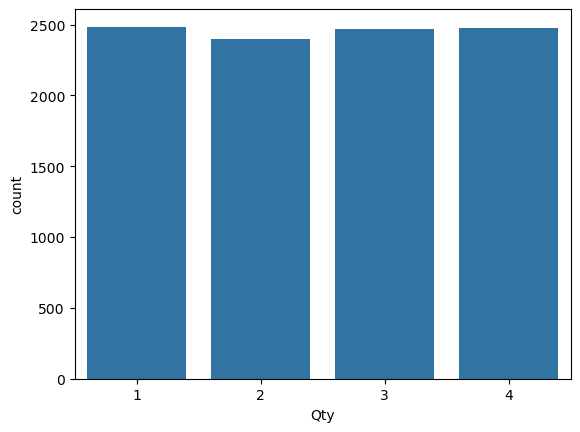

In [99]:
import seaborn as sns

sns.countplot(x = 'Qty' , data = df)

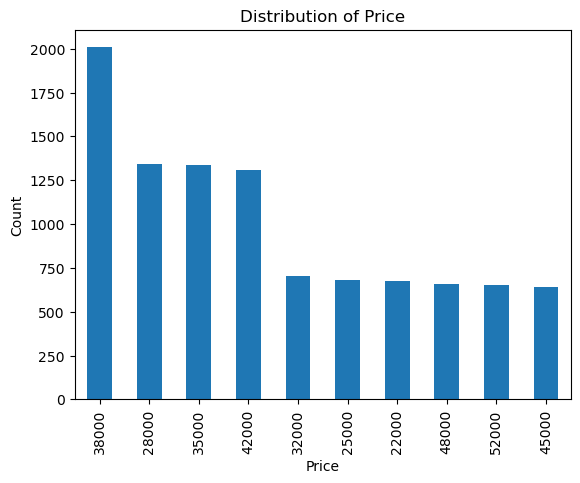

In [104]:
df['Price'].value_counts().plot(kind='bar')
plt.xlabel('Price')
plt.ylabel('Count')
plt.title('Distribution of Price')
plt.show()

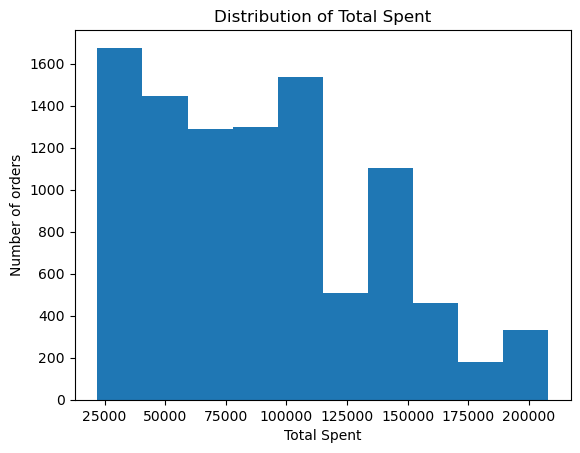

In [103]:
df['Total Spent'].plot(kind='hist')
plt.xlabel('Total Spent')
plt.ylabel('Number of orders')
plt.title('Distribution of Total Spent')
plt.show()

<Axes: >

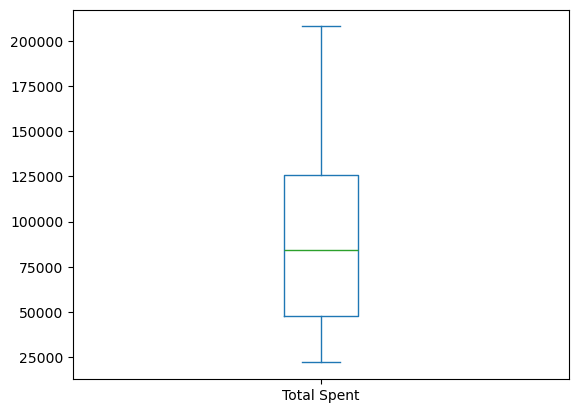

In [106]:
df['Total Spent'].plot(kind='box')